🔍 Advanced Analysis of Unified Manufacturing Data
Loading unified view...
✅ Loaded existing unified view

📈 ADVANCED ANALYSIS

1. Correlation Matrix:


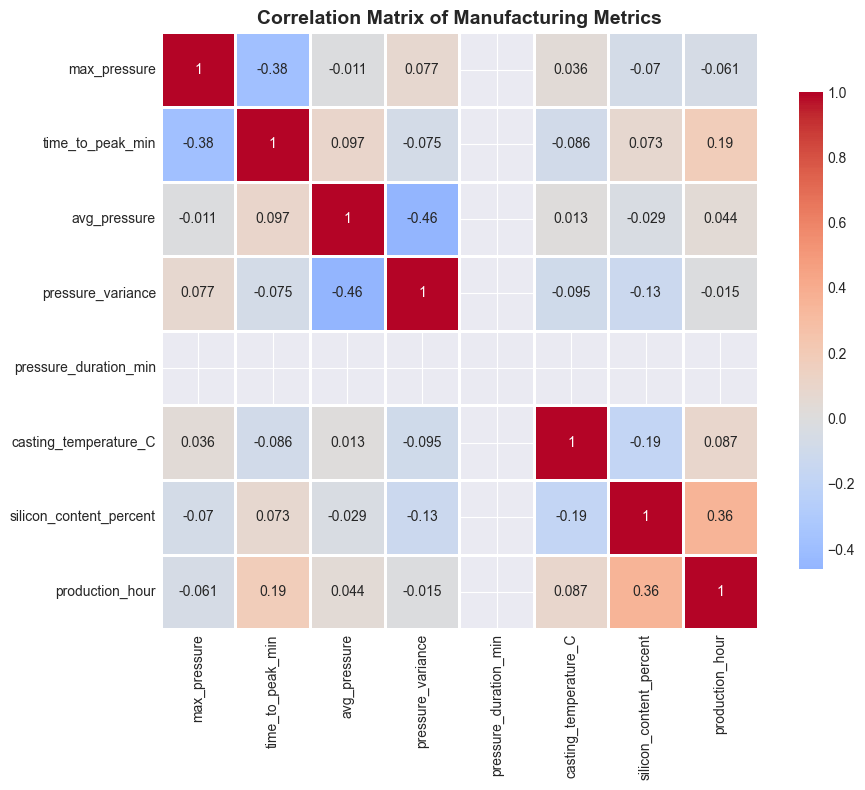


2. Time Series Analysis:


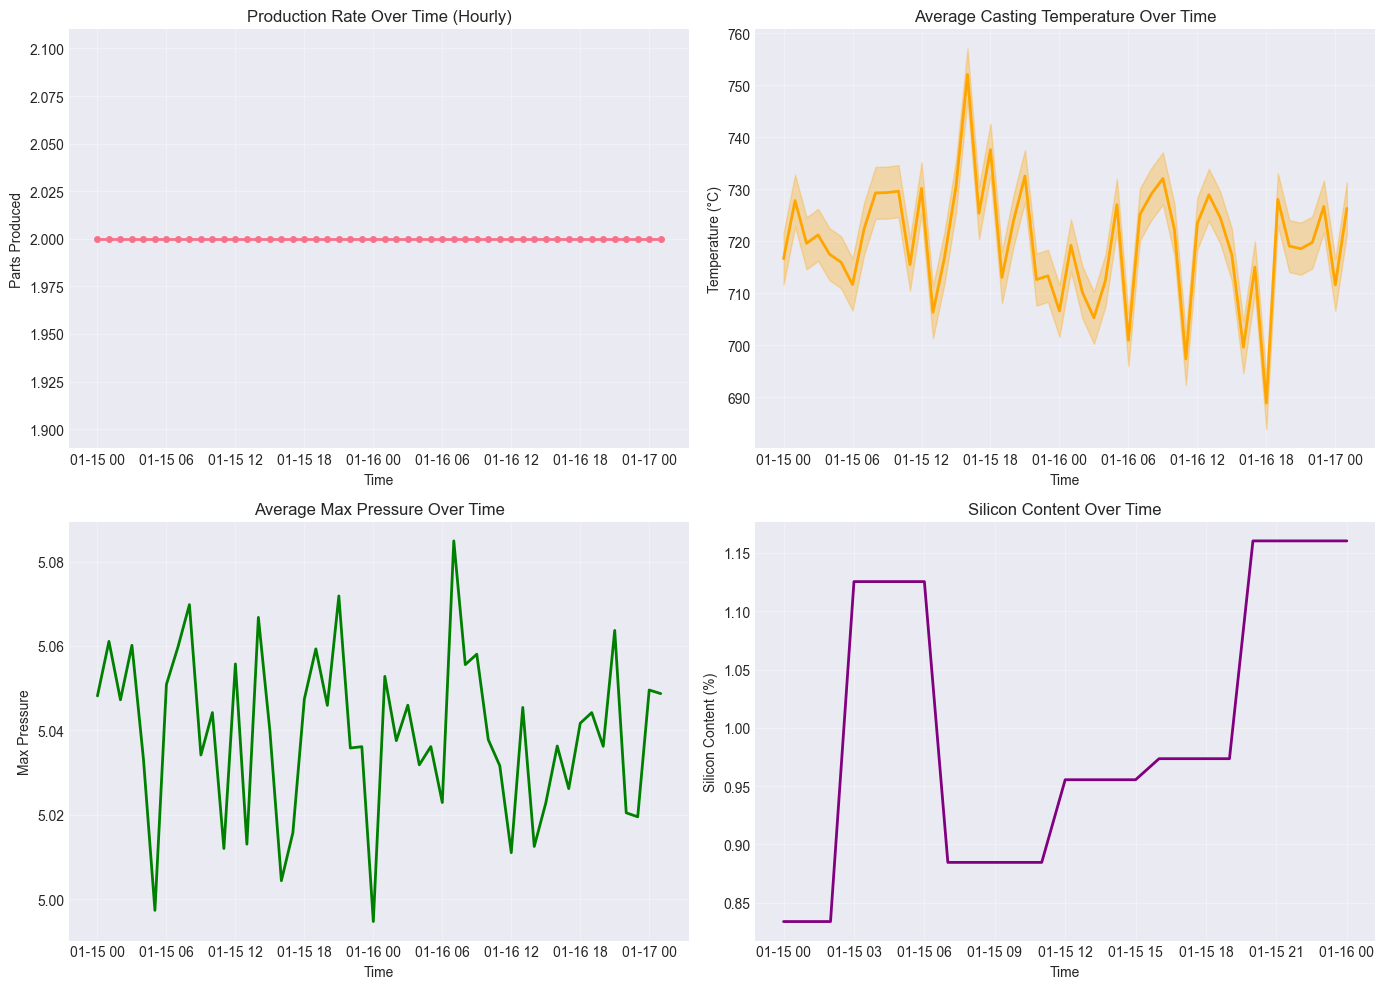


3. Statistical Analysis by Part Type:
Summary statistics by part type:
               max_pressure_mean  max_pressure_std  max_pressure_min  \
PART_TYPE                                                              
Brake_Caliper               5.04              0.03              4.99   
Engine_Block                5.04              0.03              4.97   
Gear_Casing                 5.04              0.03              5.00   
Wheel_Hub                   5.03              0.03              4.99   

               max_pressure_max  casting_temperature_C_mean  \
PART_TYPE                                                     
Brake_Caliper              5.11                      717.28   
Engine_Block               5.11                      720.63   
Gear_Casing                5.09                      726.77   
Wheel_Hub                  5.09                      714.21   

               casting_temperature_C_std  time_to_peak_min_mean  \
PART_TYPE                                        

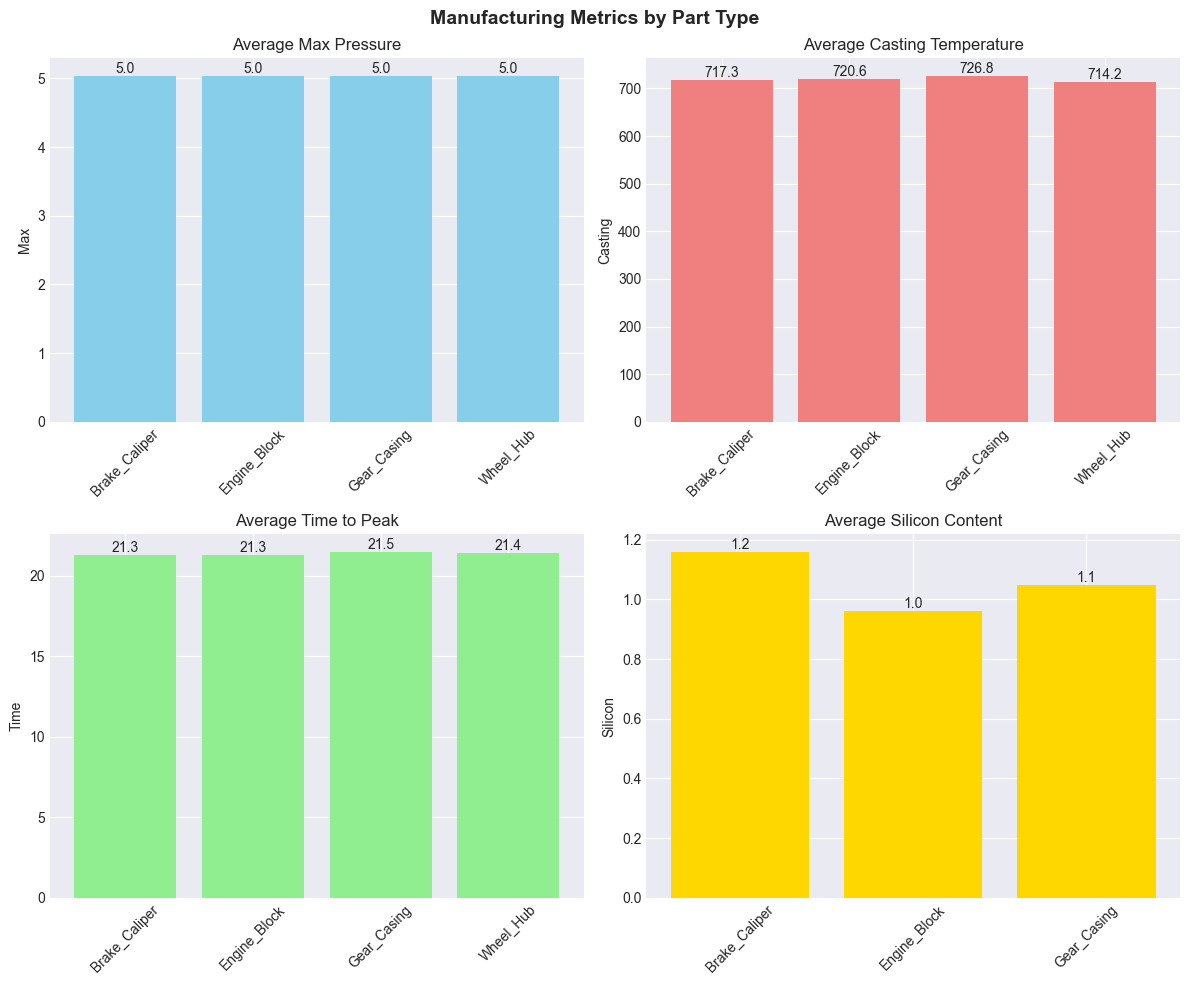


4. Quality Control Analysis:
max_pressure: 0 parts out of control limits (2.5-5.5)
casting_temperature_C: 0 parts out of control limits (650-800)
time_to_peak_min: 0 parts out of control limits (10-25)

5. Exporting detailed analysis report...
✅ Analysis report saved as 'manufacturing_analysis_report.csv'

🎯 ANALYSIS COMPLETE

Generated files:
1. unified_manufacturing_view.parquet - Complete unified dataset
2. unified_view_analysis.png - Overview visualizations
3. correlation_matrix.png - Correlation analysis
4. time_series_analysis.png - Time series trends
5. part_type_analysis.png - Part type comparisons
6. manufacturing_analysis_report.csv - Summary report


In [3]:
# This would be a Jupyter notebook. Here's the content as a Python script:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from unified import build_unified_view

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("🔍 Advanced Analysis of Unified Manufacturing Data")
print("=" * 60)

# Build or load unified view
print("Loading unified view...")
try:
    # Try to load existing unified view
    unified_df = pd.read_parquet('unified_manufacturing_view.parquet')
    print("✅ Loaded existing unified view")
except FileNotFoundError:
    # Build new unified view
    print("Building new unified view...")
    unified_df = build_unified_view()

# Advanced Analysis
print("\n📈 ADVANCED ANALYSIS")
print("=" * 60)

# 1. Correlation Analysis
print("\n1. Correlation Matrix:")
numeric_cols = unified_df.select_dtypes(include=[np.number]).columns
correlation_matrix = unified_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Manufacturing Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

# 2. Time Series Analysis
print("\n2. Time Series Analysis:")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Resample data hourly
hourly_data = unified_df.set_index('cycle_start_timestamp').resample('H').agg({
    'max_pressure': 'mean',
    'casting_temperature_C': 'mean',
    'silicon_content_percent': 'mean',
    'unique_part_identifier': 'count'
}).rename(columns={'unique_part_identifier': 'parts_produced'})

# Plot 1: Production rate
axes[0, 0].plot(hourly_data.index, hourly_data['parts_produced'], 
                linewidth=2, marker='o', markersize=4)
axes[0, 0].set_title('Production Rate Over Time (Hourly)')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Parts Produced')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Temperature trend
axes[0, 1].plot(hourly_data.index, hourly_data['casting_temperature_C'], 
                linewidth=2, color='orange')
axes[0, 1].fill_between(hourly_data.index, 
                       hourly_data['casting_temperature_C'] - 5,
                       hourly_data['casting_temperature_C'] + 5,
                       alpha=0.3, color='orange')
axes[0, 1].set_title('Average Casting Temperature Over Time')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Temperature (°C)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Pressure trend
axes[1, 0].plot(hourly_data.index, hourly_data['max_pressure'], 
                linewidth=2, color='green')
axes[1, 0].set_title('Average Max Pressure Over Time')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Max Pressure')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Silicon content
axes[1, 1].plot(hourly_data.index, hourly_data['silicon_content_percent'], 
                linewidth=2, color='purple')
axes[1, 1].set_title('Silicon Content Over Time')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Silicon Content (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series_analysis.png', dpi=150)
plt.show()

# 3. Statistical Analysis by Part Type
print("\n3. Statistical Analysis by Part Type:")
if 'PART_TYPE' in unified_df.columns:
    part_type_stats = unified_df.groupby('PART_TYPE').agg({
        'max_pressure': ['mean', 'std', 'min', 'max'],
        'casting_temperature_C': ['mean', 'std'],
        'time_to_peak_min': ['mean', 'std'],
        'silicon_content_percent': 'mean',
        'unique_part_identifier': 'count'
    }).round(2)
    
    part_type_stats.columns = ['_'.join(col).strip() for col in part_type_stats.columns.values]
    part_type_stats = part_type_stats.rename(columns={'unique_part_identifier_count': 'parts_count'})
    
    print("Summary statistics by part type:")
    print(part_type_stats)
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    metrics_to_plot = ['max_pressure_mean', 'casting_temperature_C_mean', 
                      'time_to_peak_min_mean', 'silicon_content_percent_mean']
    titles = ['Average Max Pressure', 'Average Casting Temperature', 
             'Average Time to Peak', 'Average Silicon Content']
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
    
    for idx, (metric, title, color) in enumerate(zip(metrics_to_plot, titles, colors)):
        row = idx // 2
        col = idx % 2
        axes[row, col].bar(part_type_stats.index, part_type_stats[metric], color=color)
        axes[row, col].set_title(title)
        axes[row, col].set_ylabel(metric.split('_')[0].title())
        axes[row, col].tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for i, v in enumerate(part_type_stats[metric]):
            axes[row, col].text(i, v, f'{v:.1f}', ha='center', va='bottom')
    
    plt.suptitle('Manufacturing Metrics by Part Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('part_type_analysis.png', dpi=150)
    plt.show()

# 4. Quality Control Analysis
print("\n4. Quality Control Analysis:")
# Define control limits (these would normally come from process specifications)
control_limits = {
    'max_pressure': {'lower': 2.5, 'upper': 5.5},
    'casting_temperature_C': {'lower': 650, 'upper': 800},
    'time_to_peak_min': {'lower': 10, 'upper': 25}
}

out_of_control = {}
for metric, limits in control_limits.items():
    if metric in unified_df.columns:
        lower = limits['lower']
        upper = limits['upper']
        out_of_control[metric] = ((unified_df[metric] < lower) | (unified_df[metric] > upper)).sum()
        print(f"{metric}: {out_of_control[metric]} parts out of control limits ({lower}-{upper})")

# 5. Export detailed report
print("\n5. Exporting detailed analysis report...")
report_data = {
    'total_parts': len(unified_df),
    'date_range_start': unified_df['cycle_start_timestamp'].min(),
    'date_range_end': unified_df['cycle_start_timestamp'].max(),
    'part_types': unified_df['PART_TYPE'].nunique() if 'PART_TYPE' in unified_df.columns else 0,
    'avg_max_pressure': unified_df['max_pressure'].mean(),
    'avg_temperature': unified_df['casting_temperature_C'].mean(),
    'avg_silicon': unified_df['silicon_content_percent'].mean(),
    'data_completeness': (1 - unified_df.isnull().mean().mean()) * 100
}

report_df = pd.DataFrame([report_data])
report_df.to_csv('manufacturing_analysis_report.csv', index=False)
print("✅ Analysis report saved as 'manufacturing_analysis_report.csv'")

print("\n" + "="*60)
print("🎯 ANALYSIS COMPLETE")
print("="*60)
print("\nGenerated files:")
print("1. unified_manufacturing_view.parquet - Complete unified dataset")
print("2. unified_view_analysis.png - Overview visualizations")
print("3. correlation_matrix.png - Correlation analysis")
print("4. time_series_analysis.png - Time series trends")
print("5. part_type_analysis.png - Part type comparisons")
print("6. manufacturing_analysis_report.csv - Summary report")